In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

In [4]:
print("Duplicate Records :",df.duplicated().sum())

df = df.drop_duplicates()

print("New Shape :",df.shape)

Duplicate Records : 0
New Shape : (1470, 35)


In [5]:
dictionary = pd.DataFrame({
    "Column":df.columns,
    "Datatype":df.dtypes.astype(str)
})

dictionary

,Column,Datatype
Age,Age,int64
Attrition,Attrition,object
BusinessTravel,BusinessTravel,object
DailyRate,DailyRate,int64
Department,Department,object
DistanceFromHome,DistanceFromHome,int64
Education,Education,int64
EducationField,EducationField,object
EmployeeCount,EmployeeCount,int64
EmployeeNumber,EmployeeNumber,int64


In [6]:
num = df.select_dtypes(include=['int64','float64']).columns

cat = df.select_dtypes(include=['object']).columns

print("Numerical Columns")

print(num)

print()

print("Categorical Columns")

print(cat)

Numerical Columns
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Categorical Columns
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


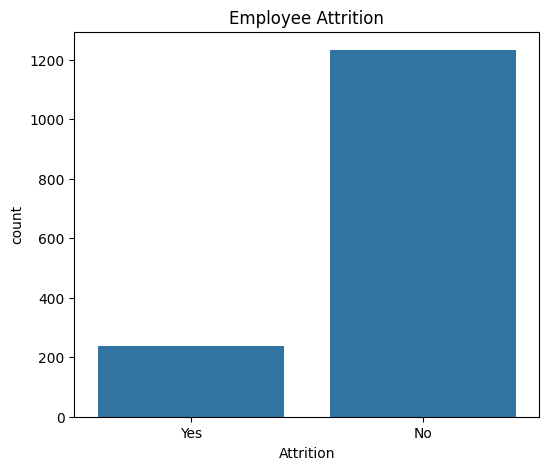

In [7]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x='Attrition')

plt.title("Employee Attrition")

plt.show()

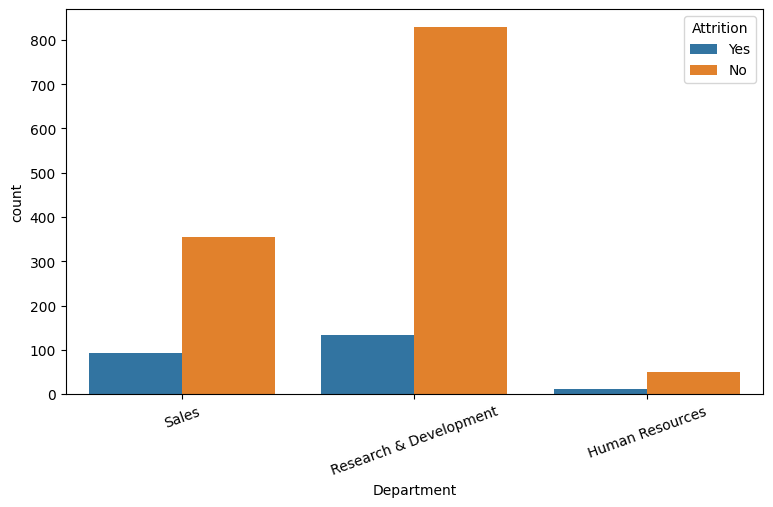

In [8]:
plt.figure(figsize=(9,5))

sns.countplot(data=df,
              x='Department',
              hue='Attrition')

plt.xticks(rotation=20)

plt.show()

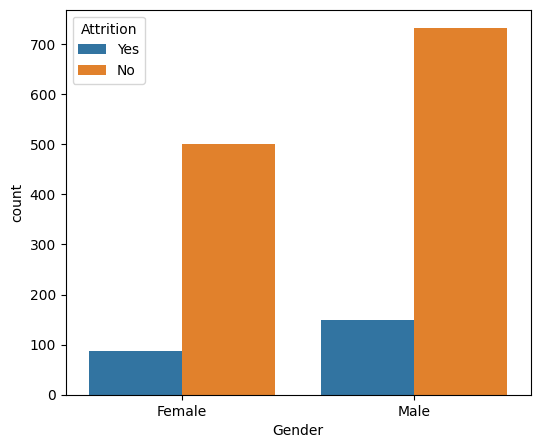

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x='Gender',
              hue='Attrition')

plt.show()

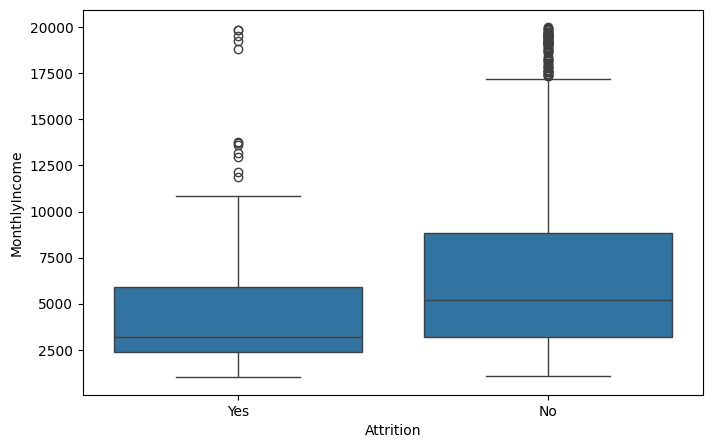

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x='Attrition',
            y='MonthlyIncome')

plt.show()

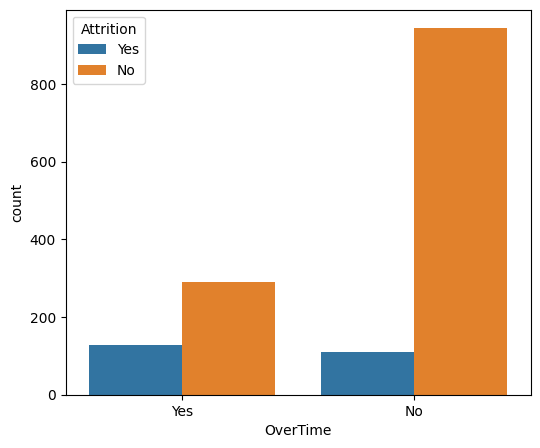

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x='OverTime',
              hue='Attrition')

plt.show()

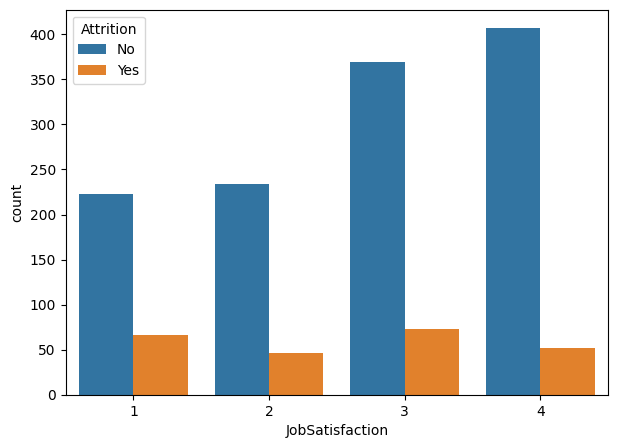

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x='JobSatisfaction',
              hue='Attrition')

plt.show()

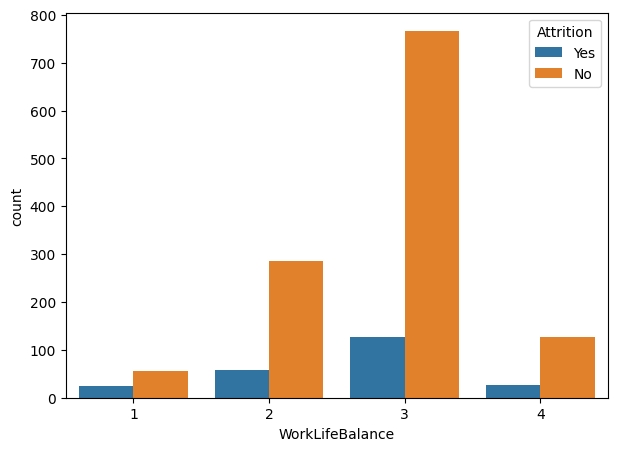

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x='WorkLifeBalance',
              hue='Attrition')

plt.show()

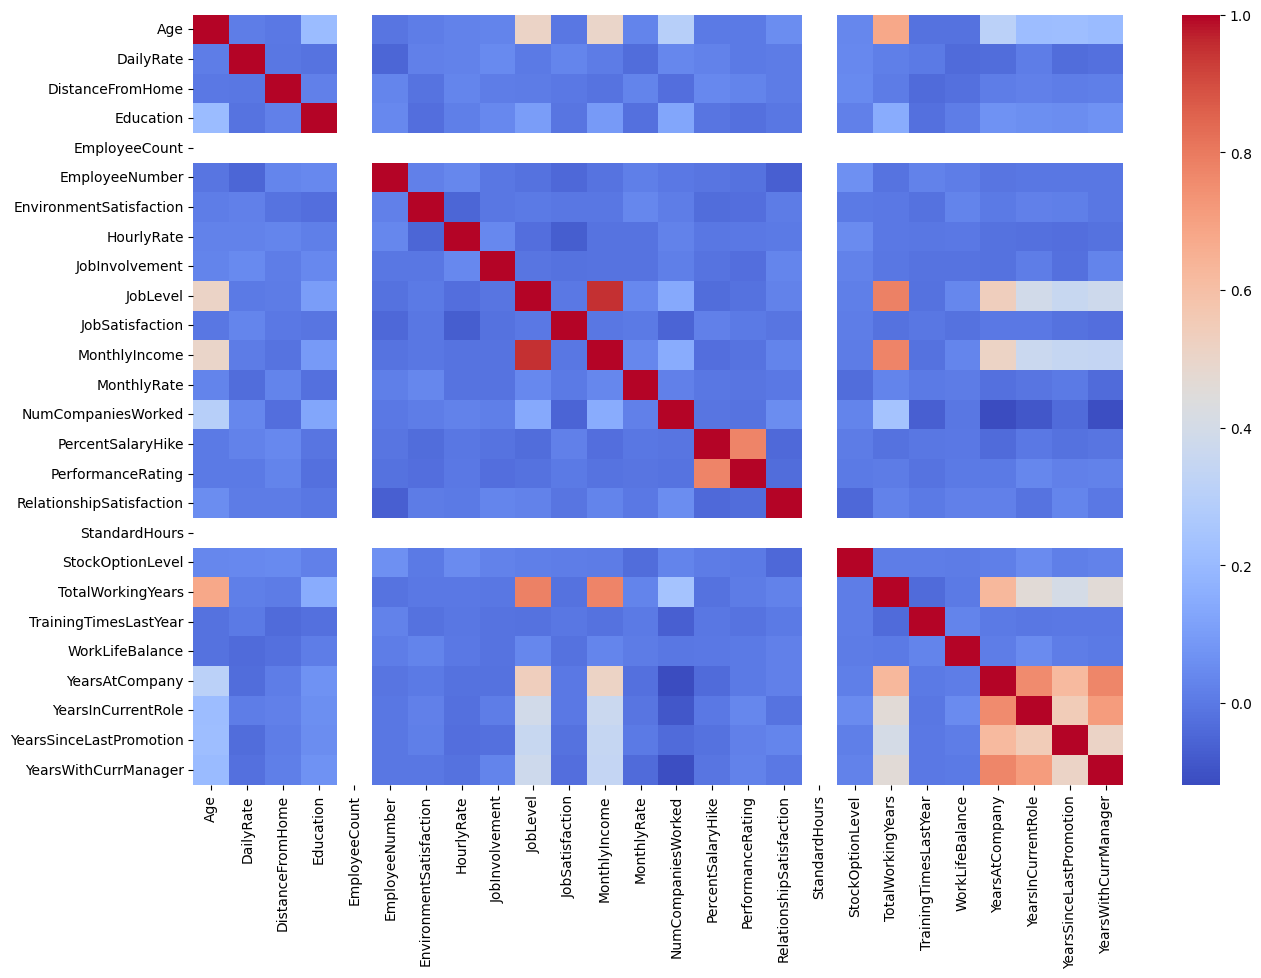

In [14]:
plt.figure(figsize=(15,10))

sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            cmap='coolwarm')

plt.show()

In [15]:
total = len(df)

attrition = len(df[df["Attrition"]=="Yes"])

active = total - attrition

rate = round((attrition/total)*100,2)

print("Total Employees :",total)

print("Active Employees :",active)

print("Attrition :",attrition)

print("Attrition Rate :",rate,"%")

print("Average Salary :",df.MonthlyIncome.mean())

print("Average Age :",df.Age.mean())

Total Employees : 1470
Active Employees : 1233
Attrition : 237
Attrition Rate : 16.12 %
Average Salary : 6502.931292517007
Average Age : 36.923809523809524


In [16]:
encoder = LabelEncoder()

for i in cat:
    df[i] = encoder.fit_transform(df[i])

In [17]:
X = df.drop("Attrition",axis=1)

y = df["Attrition"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.20,
    random_state=42
)

model = LogisticRegression(max_iter=5000)

model.fit(X_train,y_train)

prediction = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
print("Accuracy")

print(accuracy_score(y_test,prediction))

Accuracy
0.9013605442176871


In [19]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95       255
           1       0.92      0.28      0.43        39

    accuracy                           0.90       294
   macro avg       0.91      0.64      0.69       294
weighted avg       0.90      0.90      0.88       294



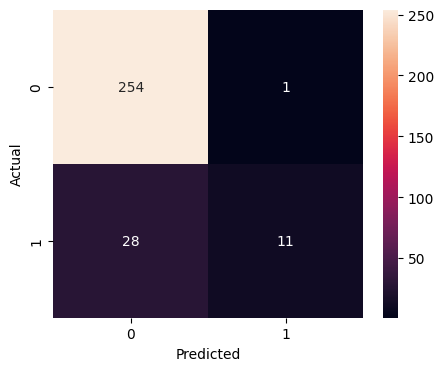

In [20]:
cm = confusion_matrix(y_test,prediction)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [21]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

importance

,Feature,Coefficient
21,OverTime,1.438848
16,MaritalStatus,0.446160
3,Department,0.271332
10,Gender,0.230068
32,YearsSinceLastPromotion,0.163572
19,NumCompaniesWorked,0.150505
30,YearsAtCompany,0.097313
5,Education,0.062106
6,EducationField,0.048824
23,PerformanceRating,0.044753


In [22]:
result = pd.DataFrame({
    "Actual":y_test,
    "Predicted":prediction
})

result.to_csv("Prediction.csv",index=False)

importance.to_csv("Feature_Importance.csv",index=False)

from google.colab import files

files.download("Prediction.csv")

files.download("Feature_Importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>